### Assignment 1 (3 scores):

- Use the Numpy library only to construct the Linear Regression model.
- Train and Evaluate that Linear Regression model on the [Forest Fires](https://archive.ics.uci.edu/static/public/162/forest+fires.zip) dataset.

Trước tiên, em tiến hành tiền xử lý bộ dữ liệu đề bài cho: cột `month` và `day` là không có thứ tự. Sau đó định nghĩa hàm `linear_regression` để tính hệ số hồi quy theo công thức OLS: $$ \hat{\beta} = (X^T X)^{-1} X^T y $$

Kiểm tra chất lượng mô hình bằng Mean Squared Error (MSE) và visualize kết quả bằng scatterplot.

Kết quả: Hệ số hồi quy, MSE

In [29]:
import numpy as np
import pandas as pd

df = pd.read_csv("forestfires.csv")

# Tiền xử lý
df = pd.get_dummies(df, columns=['month','day'], drop_first=True)
df = df.astype(float)

X = df.drop(columns=['area']).values
y = df['area'].values.reshape(-1, 1)

def linear_regression(X, y):
    X_bar = np.c_[np.ones((X.shape[0], 1)), X]
    beta = np.linalg.inv(X_bar.T @ X_bar) @ X_bar.T @ y
    return beta

def predict(X, beta):
    X_bar = np.c_[np.ones((X.shape[0], 1)), X]
    return X_bar @ beta

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# Huấn luyện & đánh giá
beta = linear_regression(X, y)
y_pred = predict(X, beta)
print('beta:', beta)
print('MSE:', mse(y, y_pred))

beta: [[-15.16401804]
 [  2.25583295]
 [ -0.14765158]
 [ -0.09527277]
 [  0.20106326]
 [ -0.12880031]
 [ -0.54416333]
 [  1.29619892]
 [ -0.13476015]
 [  1.97427446]
 [ -2.81544852]
 [ 46.882048  ]
 [ 47.3782107 ]
 [  5.58984939]
 [ 14.76908767]
 [ 28.87888659]
 [  6.71548315]
 [ -4.22255611]
 [ 12.79645676]
 [ -4.41009969]
 [ 68.97536454]
 [ 73.7319192 ]
 [  5.96928305]
 [ 19.40992987]
 [  5.14459895]
 [  9.67191999]
 [  7.79282488]
 [  5.47913767]]
MSE: 3859.0724526251065


Kết quả cho thấy MSE khá cao do cột `area` có phân phối lệch nặng (nhiều giá trị = 0),
khiến mô hình tuyến tính khó fit tốt trên toàn bộ dữ liệu.

### Assignment 2 (3 scores):

- Standardize the data so that their mean is $0$ and their variance is $1$.
- Compare the results of Linear Regression model when being trained on the original and standardized data.

#### Data normalization

The OLS estimator of a linear regression model has the form

$$
    \hat{\beta} = (X^T X)^{-1} X^T y
$$
where $X^T X \in \mathbb{R}^{K \times K}$ is called the normal matrix of the **Gram Matrix**.

Considering the convariance of $X$, we have

\begin{align}
    Cov(X)  & = \mathbb{E}[(X - \mathbb{E}[X])^2] \\
            & = \mathbb{E}[X^T X - 2 X^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X]] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X^T\mathbb{E}[X]] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X]^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - \mathbb{E}[X]^T \mathbb{E}[X] \\
\end{align}

In case we have $\mathbb{E}[X] = 0$, then $X^T X = Cov(X)$. The normalization helps we to have the numerical stability of the input, theoretically leads to stable calculation when being applied to unseen data.

Chuẩn hoá dữ liệu bằng cách dùng StandardScalẻ để mỗi feature có mean = 0, variance = 1 theo công thức: $$ X_{scaled} = \frac{X - \mu}{\sigma} $$

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

beta_scaled = linear_regression(X_scaled, y)
y_pred_scaled = predict(X_scaled, beta_scaled)

mse_scaled = mse(y, y_pred_scaled)
print(f'MSE sau chuẩn hóa: {mse_scaled:.4f}')
print(f'Chênh lệch MSE: {abs(mse(y, y_pred) - mse_scaled)}')

MSE sau chuẩn hóa: 3859.0725
Chênh lệch MSE: 9.094947017729282e-13


Ta thấy MSE không chênh lệch so với bài 1 do khi sử dụng OLS.

### Assignment 3 (2 scores):

- Perform feature engineering to remove columns that are linearly dependent (colinear) with other columns in the dataset.
- Evaluate the Linear Regression model when beeing trained on the original data and preprocessed data.

#### On the Problem of Colinearity

As stated previously, the OLS of the linear regression model is achieved by assuming that $rank(X) = K$ or $det(X) \ne 0$. So that removing columns in $X$ having colinearity with other columns is to ensure that assumption of the full rank condition of $X$. In the case $det(X) = 0$, then the **Moore-Penrose inverse** will be applied to determine the pseudo-inverse matrix of $X^T X$.

Đầu tiên, tính ma trận tương quan giữa các feature, từ đó xác định các cặp feature có độ tương quan cao.

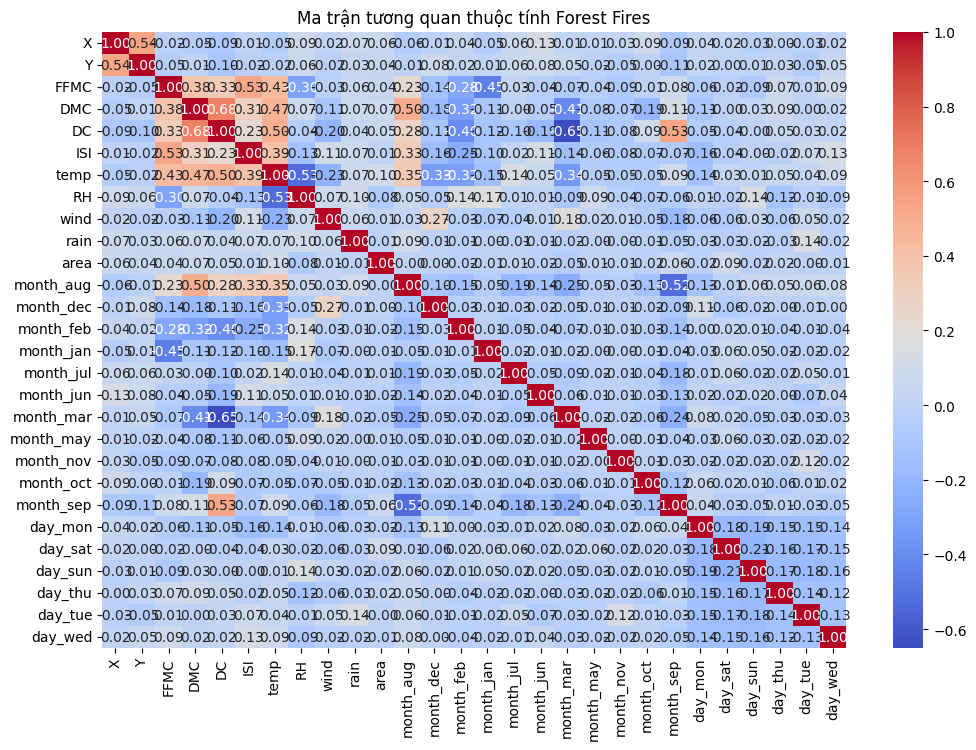

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan thuộc tính Forest Fires')
plt.show()

Nếu hai feature có tương quan quá cao (|corr| > 0.8), nên loại bỏ một cái.

In [32]:
# Loại bỏ các cột có tương quan cao
threshold = 0.8
high_corr_features = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            if colname != 'area':
                high_corr_features.add(colname)

print(f"Các cột bị loại: {high_corr_features}")

X_filtered = df.drop(columns=['area'] + list(high_corr_features)).values
beta_filtered = linear_regression(X_filtered, y)
y_pred_filtered = predict(X_filtered, beta_filtered)
mse_filtered = mse(y, y_pred_filtered)

print(f"MSE gốc (bài 1):             {mse(y, y_pred):.4f}")
print(f"MSE sau chuẩn hóa (bài 2):   {mse_scaled:.4f}")
print(f"MSE sau xử lý collinearity:  {mse_filtered:.4f}")

Các cột bị loại: set()
MSE gốc (bài 1):             3859.0725
MSE sau chuẩn hóa (bài 2):   3859.0725
MSE sau xử lý collinearity:  3859.0725


So sánh MSE trước và sau khi xử lý collinearity:

3 giá trị MSE đều bằng nhau vì không có feature nào bị loại (không có cặp nào vượt ngưỡng 0.8). Nếu có feature bị loại thì MSE có thể tăng (mất thông tin) hoặc giảm (loại bỏ nhiễu), tùy trường hợp.

### Assignment 4 (2 scores):

- Implement the Linear Regression model using Machine Learning libraries (Scikit Learn or Skorch).
- Compare the results of Linear Regression model constructed manually and from Machine Learning libraries.

Dùng LinearRegression của sklearn để kiểm tra lại kết quả.

Kết quả của mô hình từ thư viện sẽ được so sánh với mô hình được xây dựng thủ công bằng NumPy ở các bài trước.

MSE của Scikit-Learn: 3859.072452625108
So sánh kết quả:
- Mô hình NumPy (chuẩn hóa): 3859.0725
- Mô hình Scikit-Learn:       3859.0725
Chênh lệch: 4.547473508864641e-13


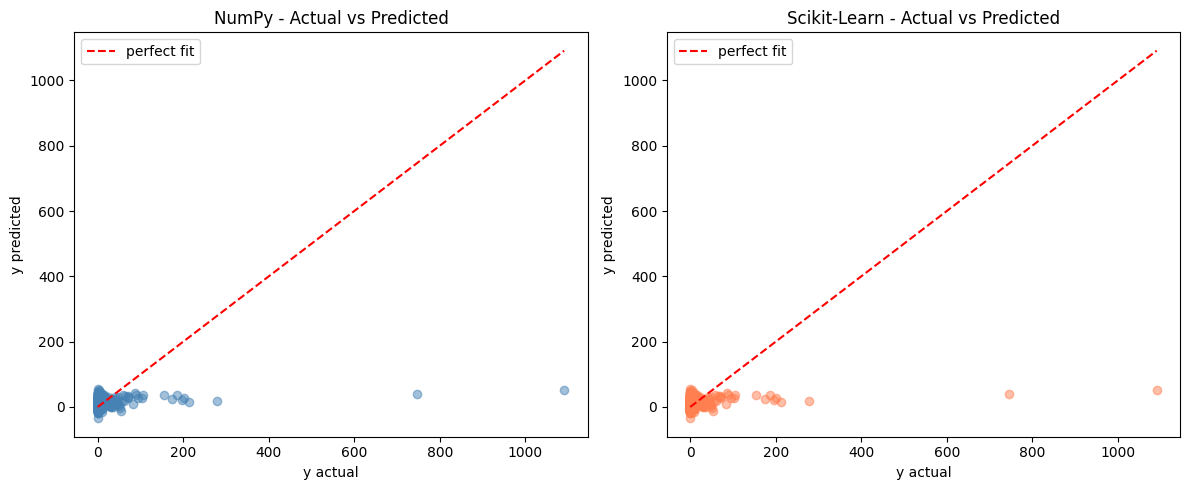

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_scaled, y)

y_sklearn_pred = model.predict(X_scaled)
MSE_sklearn = mean_squared_error(y, y_sklearn_pred)

print("MSE của Scikit-Learn:", MSE_sklearn)
print("So sánh kết quả:")
print(f"- Mô hình NumPy (chuẩn hóa): {mse_scaled:.4f}")
print(f"- Mô hình Scikit-Learn:       {MSE_sklearn:.4f}")
print(f"Chênh lệch: {abs(mse_scaled - MSE_sklearn)}")

# Visualize so sánh
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y, y_pred_scaled, alpha=0.5, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='perfect fit')
axes[0].set_xlabel('y actual')
axes[0].set_ylabel('y predicted')
axes[0].set_title('NumPy - Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y, y_sklearn_pred, alpha=0.5, color='coral')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='perfect fit')
axes[1].set_xlabel('y actual')
axes[1].set_ylabel('y predicted')
axes[1].set_title('Scikit-Learn - Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()